In [1]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 0개


ValueError: No objects to concatenate

In [ ]:
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 추정매출
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
sales_files = sorted(glob.glob(DATA_DIR + '*추정매출*.csv'))
sales = pd.concat([pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files], ignore_index=True)

# 유동인구
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')

# 영역
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')

print(f'매출: {sales.shape[0]:,}행, 유동인구: {floating.shape[0]:,}행')

매출: 519,931행, 유동인구: 46,184행


In [ ]:
#파생 데이터 준비
상권 = ['골목상권', '발달상권', '관광특구', '전통시장']
 
성별_매출 = ['남성_매출_금액', '여성_매출_금액']
성별_유동 = ['남성_유동인구_수', '여성_유동인구_수']
 
연령_매출 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
           '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령_유동 = ['연령대_10_유동인구_수','연령대_20_유동인구_수','연령대_30_유동인구_수',
           '연령대_40_유동인구_수','연령대_50_유동인구_수','연령대_60_이상_유동인구_수']
연령라벨 = ['10대', '20대', '30대', '40대', '50대', '60대+']

In [ ]:
# 상권 단위 합산
sales_demo = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
)[성별_매출 + 연령_매출 + ['당월_매출_금액']].sum().reset_index()

In [ ]:
# merge
merged_demo = sales_demo.merge(
    floating[['기준_년분기_코드', '상권_코드'] + 성별_유동 + 연령_유동 + ['총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

In [ ]:
# 비중 계산
merged_demo['남성_매출비중'] = merged_demo['남성_매출_금액'] / merged_demo['당월_매출_금액'] * 100
merged_demo['남성_유동비중'] = merged_demo['남성_유동인구_수'] / merged_demo['총_유동인구_수'].replace(0, np.nan) * 100
 
for i, 라벨 in enumerate(연령라벨):
    merged_demo[f'{라벨}_매출비중'] = merged_demo[연령_매출[i]] / merged_demo['당월_매출_금액'] * 100
    merged_demo[f'{라벨}_유동비중'] = merged_demo[연령_유동[i]] / merged_demo['총_유동인구_수'].replace(0, np.nan) * 100

In [ ]:
# %% 성별 분석
print('📊 성별: 매출비중 vs 유동인구비중')
print('-' * 75)
print(f'{"유형":<10} {"남성매출%":>10} {"남성유동%":>10} {"갭":>8} {"여성매출%":>10} {"여성유동%":>10} {"갭":>8}')
print('-' * 75)
for 구분 in 상권:
    sub = merged_demo[merged_demo['상권_구분_코드_명'] == 구분]
    남매 = sub['남성_매출비중'].mean()
    남유 = sub['남성_유동비중'].mean()
    여매 = 100 - 남매
    여유 = 100 - 남유
    print(f'{구분:<10} {남매:>9.1f}% {남유:>9.1f}% {남매-남유:>+7.1f}'
          f' {여매:>9.1f}% {여유:>9.1f}% {여매-여유:>+7.1f}')

📊 성별: 매출비중 vs 유동인구비중
---------------------------------------------------------------------------
유형              남성매출%      남성유동%        갭      여성매출%      여성유동%        갭
---------------------------------------------------------------------------
골목상권            50.8%      47.3%    +3.5      49.2%      52.7%    -3.5
발달상권            46.1%      48.9%    -2.7      53.9%      51.1%    +2.7
관광특구            42.7%      49.9%    -7.2      57.3%      50.1%    +7.2
전통시장            45.2%      47.6%    -2.4      54.8%      52.4%    +2.4


In [ ]:
# %% 연령대별 전체 평균
print('📊 연령대별: 매출비중 vs 유동인구비중 (전체)')
print('-' * 55)
print(f'{"연령대":<6} {"매출비중":>8} {"유동비중":>8} {"갭":>8}')
print('-' * 55)
for 라벨 in 연령라벨:
    매출 = merged_demo[f'{라벨}_매출비중'].mean()
    유동 = merged_demo[f'{라벨}_유동비중'].mean()
    print(f'{라벨:<6} {매출:>7.1f}% {유동:>7.1f}% {매출-유동:>+7.1f}')

📊 연령대별: 매출비중 vs 유동인구비중 (전체)
-------------------------------------------------------
연령대        매출비중     유동비중        갭
-------------------------------------------------------
10대        0.5%    13.2%   -12.8
20대       10.2%    16.4%    -6.2
30대       16.6%    17.1%    -0.5
40대       21.5%    16.3%    +5.3
50대       21.8%    15.0%    +6.8
60대+      20.5%    22.0%    -1.5


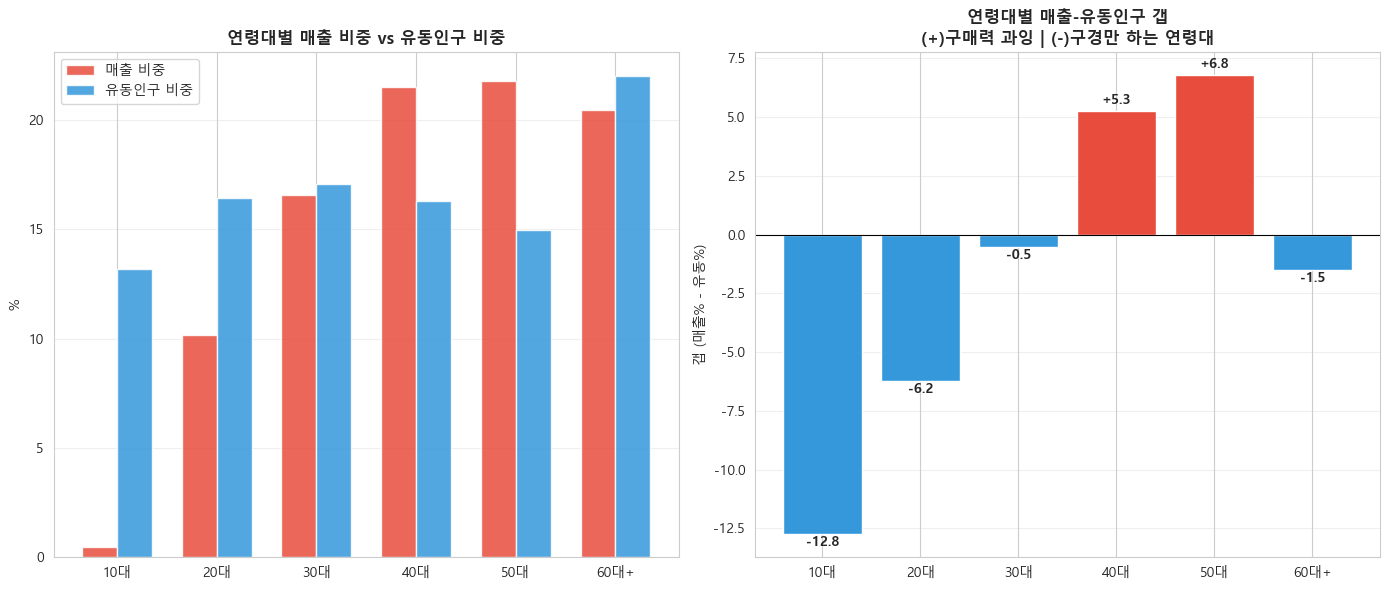

In [ ]:
# %% 연령대별 갭 시각화
매출비중_vals = [merged_demo[f'{라벨}_매출비중'].mean() for 라벨 in 연령라벨]
유동비중_vals = [merged_demo[f'{라벨}_유동비중'].mean() for 라벨 in 연령라벨]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 비중 비교
ax1 = axes[0]
x = np.arange(6)
w = 0.35
ax1.bar(x - w/2, 매출비중_vals, w, color='#E74C3C', alpha=0.85, label='매출 비중')
ax1.bar(x + w/2, 유동비중_vals, w, color='#3498DB', alpha=0.85, label='유동인구 비중')
ax1.set_xticks(x)
ax1.set_xticklabels(연령라벨)
ax1.set_ylabel('%')
ax1.set_title('연령대별 매출 비중 vs 유동인구 비중', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
 
# (2) 갭
ax2 = axes[1]
갭_vals = [m - f for m, f in zip(매출비중_vals, 유동비중_vals)]
colors = ['#E74C3C' if g > 0 else '#3498DB' for g in 갭_vals]
ax2.bar(연령라벨, 갭_vals, color=colors, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('갭 (매출% - 유동%)')
ax2.set_title('연령대별 매출-유동인구 갭\n(+)구매력 과잉 | (-)구경만 하는 연령대', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
 
for i, (bar_val, label) in enumerate(zip(갭_vals, 연령라벨)):
    ax2.text(i, bar_val + (0.3 if bar_val > 0 else -0.5),
             f'{bar_val:+.1f}', ha='center', fontweight='bold', fontsize=10)
 
plt.tight_layout()
plt.show()

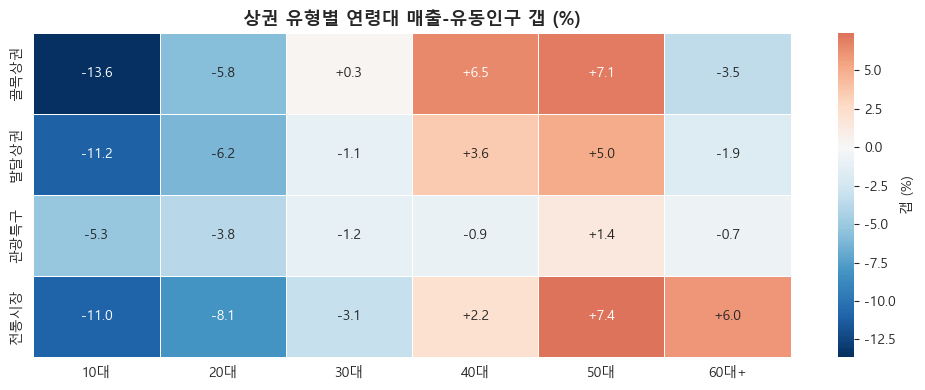

In [ ]:
# %% 상권유형별 연령대 갭 히트맵
갭_data = []
for 구분 in 상권:
    sub = merged_demo[merged_demo['상권_구분_코드_명'] == 구분]
    row = []
    for 라벨 in 연령라벨:
        매출 = sub[f'{라벨}_매출비중'].mean()
        유동 = sub[f'{라벨}_유동비중'].mean()
        row.append(매출 - 유동)
    갭_data.append(row)
 
갭_df = pd.DataFrame(갭_data, index=상권, columns=연령라벨)
 
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(갭_df, annot=True, fmt='+.1f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': '갭 (%)'})
ax.set_title('상권 유형별 연령대 매출-유동인구 갭 (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# %% 데이터 준비
sales_agg = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
).agg(
    총매출=('당월_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum')
).reset_index()
 
merged_conv = sales_agg.merge(
    floating[['기준_년분기_코드', '상권_코드', '총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
 
merged_conv['1인당_매출'] = merged_conv['총매출'] / merged_conv['총_유동인구_수'].replace(0, np.nan)
merged_conv['1인당_건수'] = merged_conv['총건수'] / merged_conv['총_유동인구_수'].replace(0, np.nan)
merged_conv['객단가'] = merged_conv['총매출'] / merged_conv['총건수'].replace(0, np.nan)

In [ ]:
 # %% 상권유형별 전환율
print('📊 상권유형별 유동인구 대비 매출 전환율')
print('-' * 80)
print(f'{"유형":<10} {"평균유동인구":>12} {"평균매출(백만)":>14} {"1인당매출(원)":>14} {"1인당건수":>10} {"객단가(원)":>12}')
print('-' * 80)
for 구분 in 상권:
    sub = merged_conv[merged_conv['상권_구분_코드_명'] == 구분]
    print(f'{구분:<10} {sub["총_유동인구_수"].mean():>11,.0f}명'
          f' {sub["총매출"].mean()/1e6:>13,.0f}'
          f' {sub["1인당_매출"].mean():>13,.0f}'
          f' {sub["1인당_건수"].mean():>9.2f}'
          f' {sub["객단가"].mean():>11,.0f}')

📊 상권유형별 유동인구 대비 매출 전환율
--------------------------------------------------------------------------------
유형               평균유동인구       평균매출(백만)       1인당매출(원)      1인당건수       객단가(원)
--------------------------------------------------------------------------------
골목상권           875,925명         3,671        42,747      0.68      42,143
발달상권         1,311,788명        54,509       155,372      3.40      33,847
관광특구         4,068,426명       204,834       288,118      7.47      32,166
전통시장           355,019명        11,099        56,392      1.97      34,478


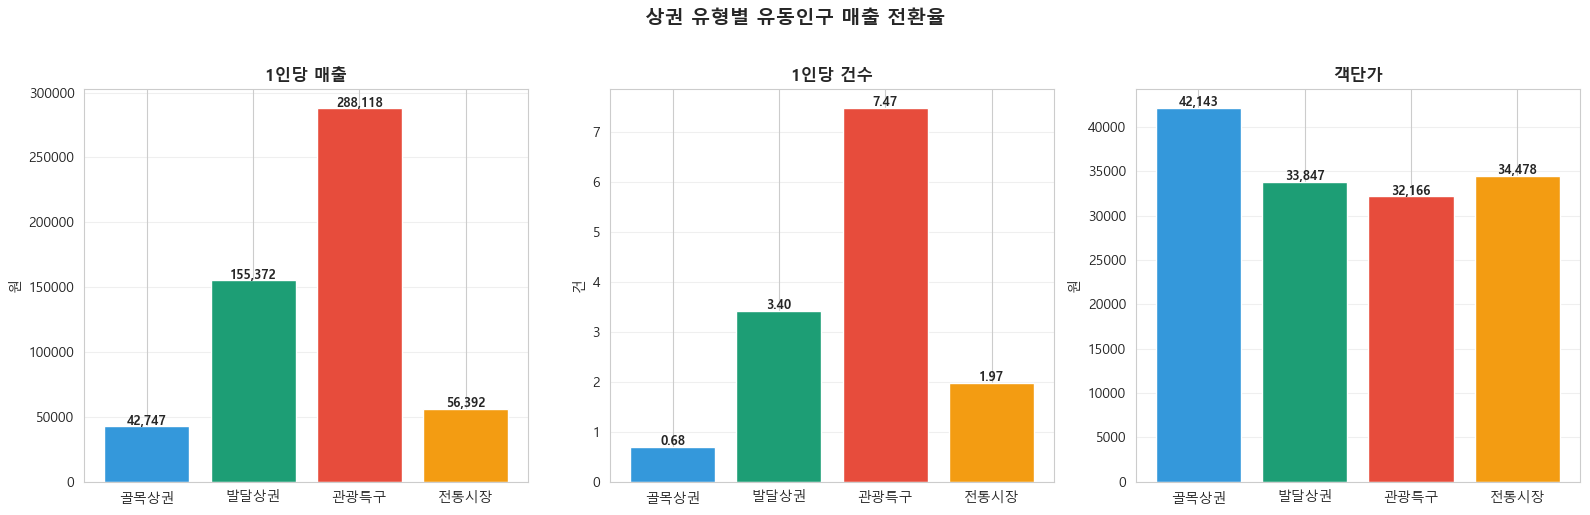

In [ ]:
# %% 전환율 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
전환_data = []
for 구분 in 상권:
    sub = merged_conv[merged_conv['상권_구분_코드_명'] == 구분]
    전환_data.append({
        '유형': 구분,
        '1인당매출': sub['1인당_매출'].mean(),
        '1인당건수': sub['1인당_건수'].mean(),
        '객단가': sub['객단가'].mean()
    })
전환_df = pd.DataFrame(전환_data)
 
색상 = ['#3498DB', '#1D9E75', '#E74C3C', '#F39C12']
 
# (1) 1인당 매출
ax1 = axes[0]
bars = ax1.bar(전환_df['유형'], 전환_df['1인당매출'], color=색상, edgecolor='white')
ax1.set_ylabel('원')
ax1.set_title('1인당 매출', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, 전환_df['1인당매출']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
 
# (2) 1인당 건수
ax2 = axes[1]
bars2 = ax2.bar(전환_df['유형'], 전환_df['1인당건수'], color=색상, edgecolor='white')
ax2.set_ylabel('건')
ax2.set_title('1인당 건수', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, 전환_df['1인당건수']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
 
# (3) 객단가
ax3 = axes[2]
bars3 = ax3.bar(전환_df['유형'], 전환_df['객단가'], color=색상, edgecolor='white')
ax3.set_ylabel('원')
ax3.set_title('객단가', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, 전환_df['객단가']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
 
plt.suptitle('상권 유형별 유동인구 매출 전환율', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 분기별 매출 전환율(1인당 매출) 추이
### 코로나 이후 전환율이 어떻게 변화했는지, 상권 유형별 회복 속도 차이 확인

In [ ]:
# %% 분기별 전환율 계산
# 이상치 방지: 유동인구 1,000명 미만 상권 제외 + 중앙값 사용
merged_conv_clean = merged_conv[merged_conv['총_유동인구_수'] >= 1000].copy()
 
trend = merged_conv_clean.groupby(['기준_년분기_코드', '상권_구분_코드_명']).agg(
    중앙_1인당매출=('1인당_매출', 'median'),
    평균매출=('총매출', 'mean'),
    평균유동=('총_유동인구_수', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

In [ ]:
# 분기 라벨
def to_label(q):
    return f'{q//10}Q{q%10}'
 
trend['분기라벨'] = trend['기준_년분기_코드'].apply(to_label)

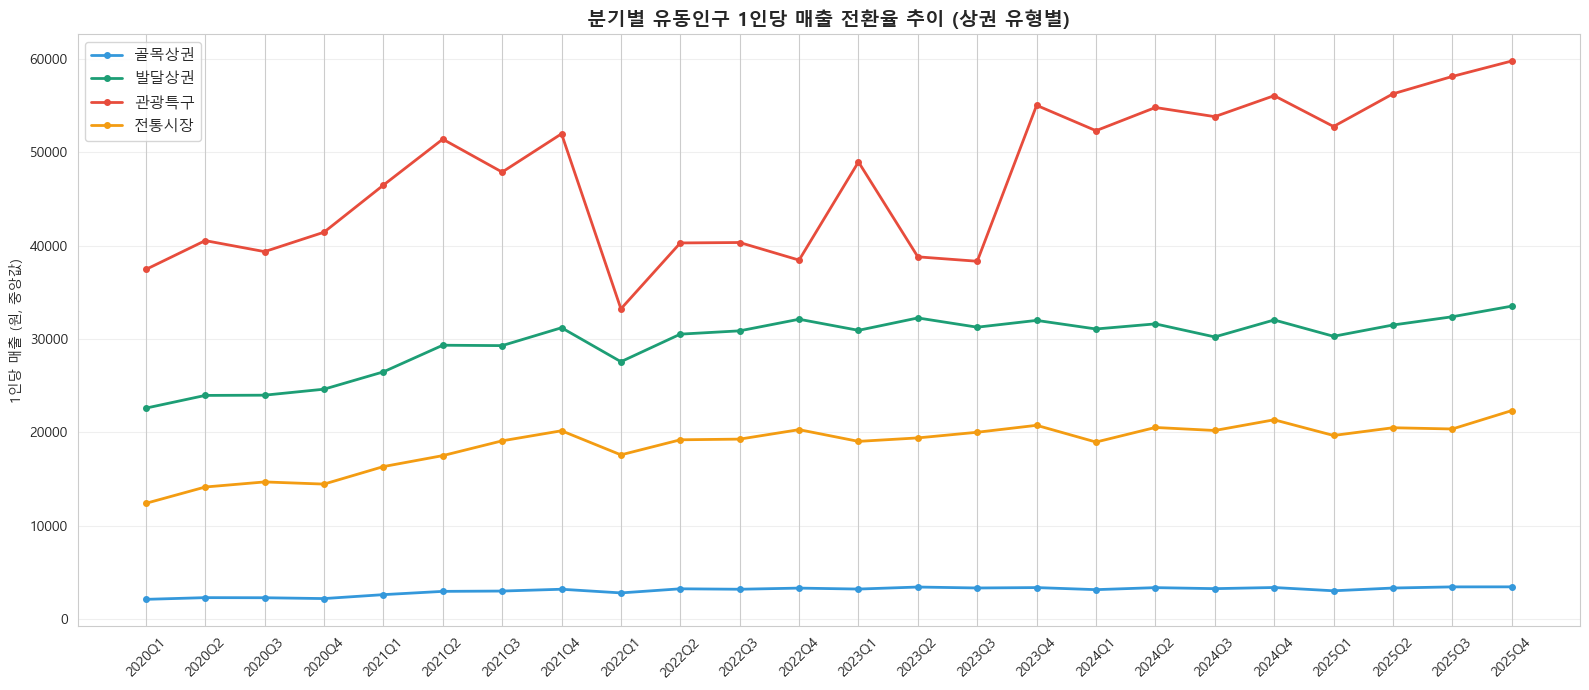

In [ ]:
# %% 전환율 추이 꺾은선 그래프
색상 = {'골목상권':'#3498DB', '발달상권':'#1D9E75', '관광특구':'#E74C3C', '전통시장':'#F39C12'}
순서 = ['골목상권', '발달상권', '관광특구', '전통시장']
 
fig, ax = plt.subplots(figsize=(16, 7))
 
for 구분 in 순서:
    sub = trend[trend['상권_구분_코드_명'] == 구분].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['중앙_1인당매출'],
            marker='o', markersize=4, linewidth=2,
            color=색상[구분], label=구분)
 
ax.set_ylabel('1인당 매출 (원, 중앙값)')
ax.set_title('분기별 유동인구 1인당 매출 전환율 추이 (상권 유형별)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
 
 
plt.tight_layout()
plt.show()

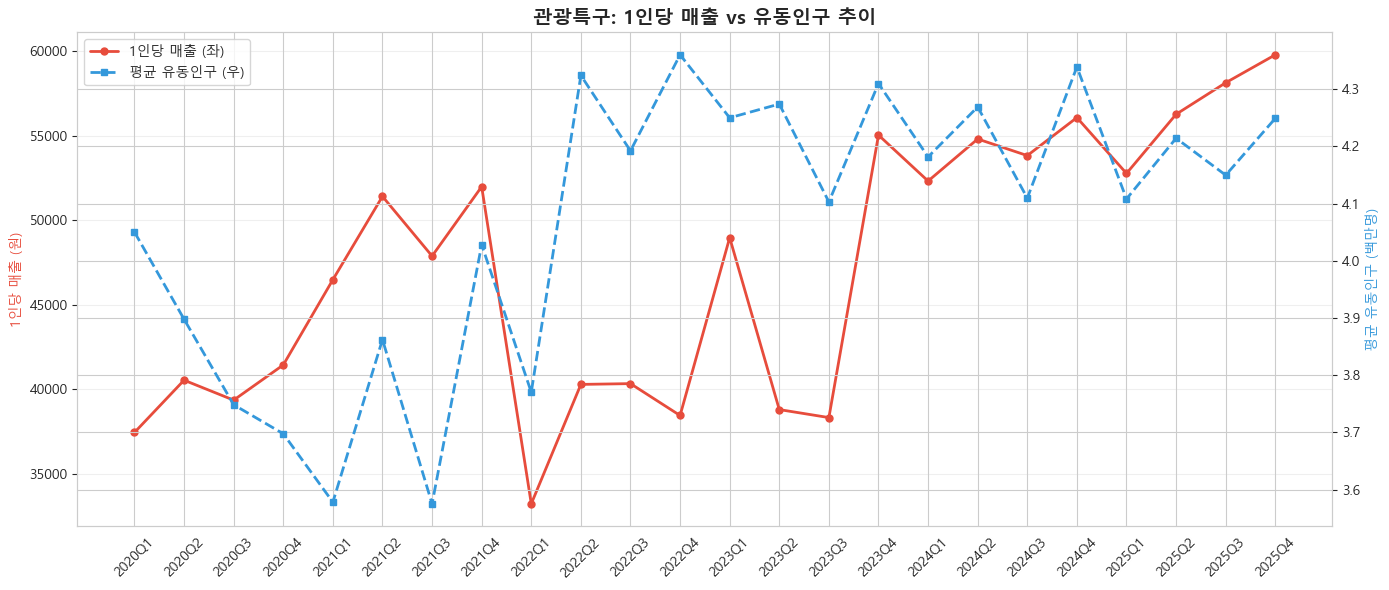

In [ ]:
# %% 전환율 + 유동인구 이중축 (관광특구만)
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
 
관광 = trend[trend['상권_구분_코드_명'] == '관광특구'].sort_values('기준_년분기_코드')
 
line1 = ax1.plot(관광['분기라벨'], 관광['중앙_1인당매출'],
                 color='#E74C3C', marker='o', markersize=5, linewidth=2, label='1인당 매출 (좌)')
line2 = ax2.plot(관광['분기라벨'], 관광['평균유동']/1e6,
                 color='#3498DB', marker='s', markersize=4, linewidth=2, linestyle='--', label='평균 유동인구 (우)')
 
ax1.set_ylabel('1인당 매출 (원)', color='#E74C3C')
ax2.set_ylabel('평균 유동인구 (백만명)', color='#3498DB')
ax1.set_title('관광특구: 1인당 매출 vs 유동인구 추이', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
 
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=10)
 
plt.tight_layout()
plt.show()

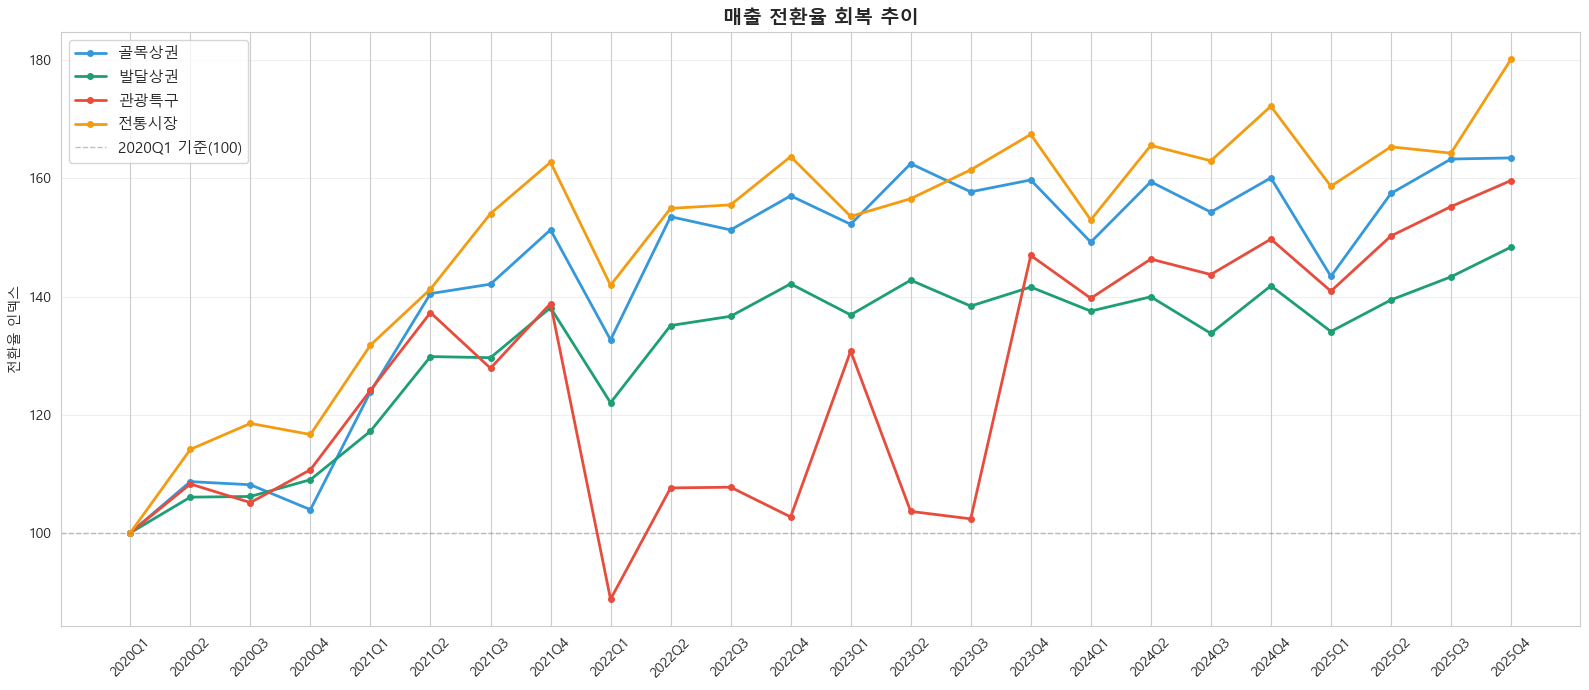

In [ ]:
# %% 2020Q1 = 100 기준 인덱스 추이
fig, ax = plt.subplots(figsize=(16, 7))
 
for 구분 in 순서:
    sub = trend[trend['상권_구분_코드_명'] == 구분].sort_values('기준_년분기_코드')
    base = sub['중앙_1인당매출'].iloc[0]
    sub_idx = sub['중앙_1인당매출'] / base * 100
    ax.plot(sub['분기라벨'], sub_idx,
            marker='o', markersize=4, linewidth=2,
            color=색상[구분], label=구분)
 
ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='2020Q1 기준(100)')
ax.set_ylabel('전환율 인덱스')
ax.set_title('매출 전환율 회복 추이', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# %% 전환율 출력
print('📊 분기별 1인당 매출 전환율 (중앙값, 유동인구 1,000명 이상)')
print('-' * 55)
for 구분 in 순서:
    sub = trend[trend['상권_구분_코드_명'] == 구분].sort_values('기준_년분기_코드')
    first = sub['중앙_1인당매출'].iloc[0]
    last = sub['중앙_1인당매출'].iloc[-1]
    peak = sub['중앙_1인당매출'].max()
    peak_q = sub.loc[sub['중앙_1인당매출'].idxmax(), '분기라벨']
    print(f'\n▸ {구분}')
    print(f'  2020Q1: {first:,.0f}원 → 최신: {last:,.0f}원 (변화: {(last/first-1)*100:+.1f}%)')
    print(f'  최고점: {peak:,.0f}원 ({peak_q})')

📊 분기별 1인당 매출 전환율 (중앙값, 유동인구 1,000명 이상)
-------------------------------------------------------

▸ 골목상권
  2020Q1: 2,110원 → 최신: 3,449원 (변화: +63.5%)
  최고점: 3,449원 (2025Q4)

▸ 발달상권
  2020Q1: 22,596원 → 최신: 33,523원 (변화: +48.4%)
  최고점: 33,523원 (2025Q4)

▸ 관광특구
  2020Q1: 37,452원 → 최신: 59,786원 (변화: +59.6%)
  최고점: 59,786원 (2025Q4)

▸ 전통시장
  2020Q1: 12,395원 → 최신: 22,331원 (변화: +80.2%)
  최고점: 22,331원 (2025Q4)
